In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import patheffects
import numpy as np
from utils import *

In [2]:
def solver_name_to_precision(name):
    preconditioner_prec = name.split(".")[1].split(",")[0]
    if "Inv(torch." not in name:
        return preconditioner_prec
    else:
        inv_prec = name.split("Inv(torch.")[1].split(")")[0]
        return f"{preconditioner_prec}+{inv_prec}"


def solver_name_to_preconditioner(name):
    if "CG" in name:
        name = name.split("CG(")[1]
    return name.split("(")[0]

In [3]:
def generate_summary(df: pd.DataFrame):
    if "solve times" not in df.columns:
        return pd.DataFrame()

    df = df.copy()
    metadata_df = df.apply(extract_row_metadata, axis=1)
    metadata_cols = metadata_df.columns.tolist()
    df = pd.concat([df, metadata_df], axis=1)

    df["precision"] = df["solver"].apply(solver_name_to_precision)
    df["preconditioner"] = df["solver"].apply(solver_name_to_preconditioner)
    df["fine m"] = df["fine m"].apply(lambda x: int(x[1:]))
    df["coarse m"] = df["coarse m"].apply(lambda x: int(x[1:]))
    pivot_table = df.pivot_table(
        index=["dim", "p", "fine m", "coarse m"],
        columns=["preconditioner", "precision"],
        values=metadata_cols,
        aggfunc="min",
    )
    return pivot_table

In [4]:
df = pd.read_csv("../results/experiment_precisions.csv")
df = process_experiments_df(df)
summary = generate_summary(df)
summary

cg setup time                                   \
preconditioner        AdditiveSchwarz                                    
precision                     float32 float32+bfloat16 float32+float16   
dim p fine m coarse m                                                    
2D  1 10     8            3000.231689      2633.682617     2909.245605   
             9            3543.291260      3510.127686     3380.208740   
             10           5573.378418      5289.880859     5663.708008   
      11     9            4546.794922      4599.364746     4167.757324   
             10           6306.523926      6431.620117     6255.624512   
             11          13858.452148     13511.721680    13605.061523   
    3 9      7            3294.922607      3199.558838     3345.433838   
             8            3768.400391      3340.524170     3292.430176   
             9            4210.413574      4020.383057     4021.822266   
    5 8      6            3253.007080      3228.618652     3632.692383   
             7            3175.211426      3096.135742     3110.321045   
             8            3683.703125      3677.481445     3374.033936   

                                                                      \
preconditioner                                                         
precision                   float64 float64+bfloat16 float64+float16   
dim p fine m coarse m                                                  
2D  1 10     8          3214.224121      2887.568604     2713.788574   
             9          3767.523682      3919.766602     3504.618164   
             10         5586.321289      5637.814941     5208.485352   
      11     9          4220.716797      4713.993652     4359.318848   
             10         5916.655273      6506.026855     6282.979492   
             11        14567.364258     13396.513672    13429.696289   
    3 9      7          3232.541748      3243.931641     3308.454346   
             8          3803.607910      3827.186523     3783.635254   
             9          3980.033203      4176.948730     4240.506348   
    5 8      6          3856.208008      3327.832275     3382.001221   
             7          3122.118652      3150.035645     3297.317871   
             8          3717.931641      3677.401367     3704.595459   

                                                                      \
preconditioner                        HybridSchwarz                    
precision             float64+float32       float64 float64+bfloat16   
dim p fine m coarse m                                                  
2D  1 10     8            2740.994141   3129.910645      2996.823242   
             9            3566.945312   3764.774170      3737.022705   
             10           5638.697754   5357.176270      5342.826660   
      11     9            4306.128418   5081.492676      5398.481934   
             10           5991.948730   6904.055664      6825.459961   
             11          13410.938477  13950.553711     14079.673828   
    3 9      7            3320.048828   3612.747559      3722.598877   
             8            3816.245361   4035.185791      4096.467773   
             9            4215.668945   4742.714355      4540.413574   
    5 8      6            3334.949219   3989.192383      3978.777588   
             7            3642.692383   3677.353271      3682.753906   
             8            3681.153809   4035.411133      4066.012695   

                                       ... preconditioner time  \
preconditioner                         ...     AdditiveSchwarz   
precision             float64+float16  ...    float64+bfloat16   
dim p fine m coarse m                  ...                       
2D  1 10     8            2978.940918  ...            1.962790   
             9            3682.950195  ...            4.197318   
             10           5375.340332  ...           14.006343   
      11     9            4787.036133  ...            6.407242   
     

In [5]:
def shorten_precision(prec):
    return "+".join(
        [("fp" if p.startswith("f") else "bf") + p[-2:] for p in prec.split("+")]
    )

## Sanity check

In [6]:
experiments = summary.index.droplevel("coarse m").unique().to_list()
experiments

[('2D', 1, 10), ('2D', 1, 11), ('2D', 3, 9), ('2D', 5, 8)]

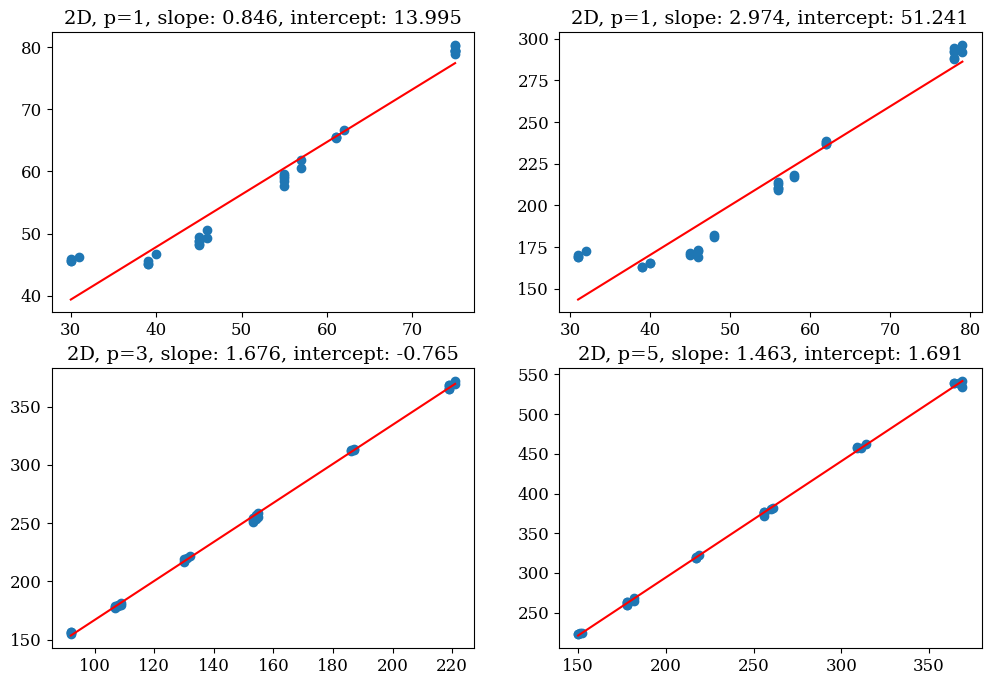

In [7]:
from sklearn.linear_model import LinearRegression

ncols = 2
nrows = (len(experiments) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
for i, (dim, p, fine_m) in enumerate(experiments):
    ax = axes.flatten()[i]

    sp = summary.xs(dim, level="dim").xs(p, level="p").xs(fine_m, level="fine m")
    iters = sp["iterations"].values.flatten()
    cg_time = (
        sp["cg time"] - sp["preconditioner time"] * sp["iterations"]
    ).values.flatten()
    # cg_time = cg_time[~np.isnan(cg_time)]
    cg_time = cg_time[iters < 600]
    iters = iters[iters < 600]
    ax.scatter(iters, cg_time)

    model = LinearRegression().fit(iters.reshape(-1, 1), cg_time)
    ax.set_title(
        f"{dim}, p={p}, slope: {model.coef_[0]:.3f}, intercept: {model.intercept_:.3f}"
    )

    itx = np.linspace(iters.min(), iters.max(), 100).reshape(-1, 1)
    predicted = model.predict(itx)
    ax.plot(itx, predicted, color="red", label="Linear fit")

## Iteration count table

In [8]:
nice_col_names = {
    "p": "$p$",
    "fine m": "$m$",
    "solvers m": "$M$",
    "coarse m": "$\\mathcal{M}$",
}

precisions_order = [
    "float64",
    "float64+float32",
    "float64+float16",
    "float64+bfloat16",
    "float32",
    "float32+float16",
    "float32+bfloat16",
]

iter_summary = summary["iterations"].copy()

iter_summary = iter_summary.reindex(
    columns=pd.Index(
        iter_summary.columns.levels[1],
        name="precision",
    ).reindex(
        precisions_order
    )[0],
    level="precision",
)

formatted_iter_table = iter_summary.astype(int).style.format_index(
    lambda prec: f"{{\\texttt{{{shorten_precision(prec)}}}}}",
    axis=1,
    level="precision",
)
formatted_iter_table.index.rename(nice_col_names, inplace=True)
formatted_iter_table.columns.name = None


def highlight_values(s):
    return (
        [""]
        + [
            "color: #ff0000;" if v > 500 else "color: #aaaaaa" if v == s.iloc[0] else ""
            for v in s[1:7]
        ]
        + [""]
        + [
            "color: #ff0000;" if v > 400 else "color: #aaaaaa" if v == s.iloc[7] else ""
            for v in s[8:]
        ]
    )


formatted_iter_table = formatted_iter_table.apply(highlight_values, axis=1)

formatted_iter_table

In [9]:
# iter_table_latex = formatted_iter_table.to_latex(
#     hrules=True,
#     multirow_align="t",
#     column_format="rrrr|"
#     + 7 * "S[table-format=3, table-column-width=2em]"
#     + "|"
#     + 4 * "S[table-format=3, table-column-width=2em]",
#     convert_css=True,
# )
# latex_lines = iter_table_latex.split("\n")
# first_header_line = latex_lines.index("\\toprule") + 1
# last_header_line = latex_lines.index("\\midrule") - 1
# column_names = [None] * len(latex_lines[first_header_line + 1].split("&"))
# for line in latex_lines[first_header_line + 1 : last_header_line + 1]:
#     line_col_names = [x.strip().removesuffix("\\\\") for x in line.split("&")]
#     for i, col_name in enumerate(line_col_names):
#         if col_name:
#             column_names[i] = col_name
# single_header_line = " & ".join(column_names) + " \\\\"
# hacked_pivot_latex = "\n".join(
#     latex_lines[:first_header_line]
#     + [single_header_line]
#     + latex_lines[last_header_line + 1 :]
# )
# with open("../docs/tables/experiment_precision_iterations.tex", "w") as f:
#     f.write(hacked_pivot_latex)

## Plots

In [10]:
def get_plot_df(dim, p, fine_m, precision, preconditioner):
    data = (
        summary.xs(p, level="p")
        .xs(dim, level="dim")
        .xs(fine_m, level="fine m")
        .xs(precision, level="precision", axis=1)
        .xs(preconditioner, level="preconditioner", axis=1)
        .reset_index()
        .set_index("coarse m")
    )

    if "cg time" not in data.columns:
        return None

    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    total_preconditioner_rest = "other preconditioner components"
    total_not_preconditioner = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_preconditioner_rest] = (
        data["preconditioner time"]
        - data["local solvers time"]
        - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_preconditioner] = (
        data["cg time"]
        - data[total_preconditioner_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[
            [
                total_not_preconditioner,
                total_preconditioner_rest,
                total_coarse_solver,
                total_local_solvers,
            ]
        ]
        / 1000
    )
    return to_plot

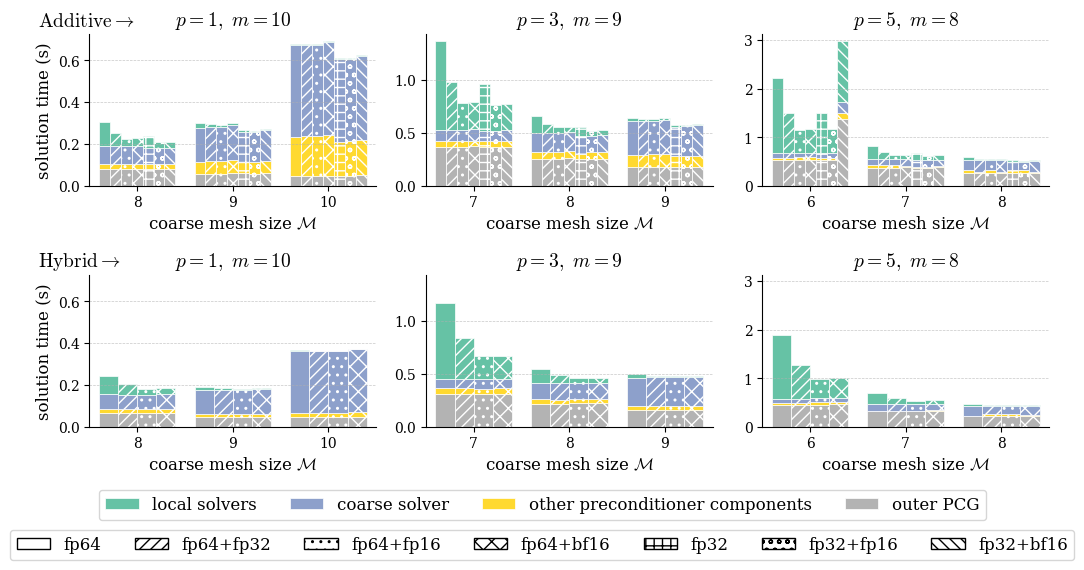

In [11]:
experiments_to_plot = [("2D", 1, 10), ("2D", 3, 9), ("2D", 5, 8)]

fig, axes = plt.subplots(
    2, len(experiments_to_plot), figsize=(10.5, 5), layout="tight", sharey="col"
)
hatch_list = ["", "///", "..", "xx", "++", "oo", "\\\\\\"]
for i, preconditioner in enumerate(("AdditiveSchwarz", "HybridSchwarz")):
    precisions = summary.columns.levels[2].to_list()
    prec_prec = set(summary["iterations"].columns.to_list())
    precisions = [prec for prec in precisions if (preconditioner, prec) in prec_prec]

    for j, (dim, p, fine_m) in enumerate(experiments_to_plot):
        ax = axes[i, j]

        plot_clustered_stacked(
            ax,
            list(
                filter(
                    lambda x: x is not None,
                    [
                        get_plot_df(dim, p, fine_m, precision, preconditioner)
                        for precision in precisions_order
                    ],
                )
            ),
            precisions,
            hatch_list=hatch_list,
            add_legend=False,
        )
        m = (
            summary.xs(dim, level="dim")
            .xs(p, level="p")
            .index.get_level_values("fine m")[0]
        )
        ax.set_title(f"$p={p},\\ m={m}$")
        ax.set_xlabel("coarse mesh size $\\mathcal{M}$")
        if j == 0:
            ax.set_ylabel("solution time (s)")
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.tick_params(axis="both", which="minor", labelsize=8)

fig.text(0.02, 0.93, "$\\text{Additive}\\rightarrow$", fontsize=14)
fig.text(0.02, 0.45, "$\\text{Hybrid}\\rightarrow$", fontsize=14)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncols=4,
)

proxies = []
for i, prec in enumerate(precisions_order):
    p = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatch_list[i] or "",
        label=prec,
    )
    proxies.append(p)
fig.legend(
    proxies,
    map(shorten_precision, precisions_order),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncols=7,
)
fig.savefig("../docs/images/precision_plots.svg", bbox_inches="tight")

## Convergence history

In [12]:
def convergence_plot(
    ax,
    df: pd.DataFrame,
    label_y: list[float],
    label_offset: int = 8,
    label_pad: int = 1,
    xlim: int | None = None,
    first_iter: int | None = None,
    max_iters: int | None = None,
):
    df_prec = df.apply(lambda row: solver_name_to_precision(row["solver"]), axis=1)

    for i, prec in enumerate(precisions_order):
        res_norms = df[df_prec == prec].iloc[0]["metadata"]["residual norms"]
        if first_iter is not None:
            res_norms = res_norms[first_iter:]
        if max_iters is not None:
            res_norms = res_norms[:max_iters]

        ax.plot(res_norms, label=shorten_precision(prec), linestyle="--")

        x_start = len(res_norms) - 1
        y_start = res_norms[-1]
        x_end = x_start + label_offset
        y_end = 10 ** (label_y[i])

        ax.plot(
            [x_start, (x_start + x_end - label_pad) / 2, x_end - label_pad],
            [y_start, y_end, y_end],
            color=ax.get_lines()[-1].get_color(),
            alpha=0.5,
            linestyle=":",
        )
        ax.text(
            x_end,
            y_end,
            shorten_precision(prec),
            va="center",
            fontsize=11,
            color=ax.get_lines()[-1].get_color(),
            path_effects=[patheffects.withStroke(linewidth=3, foreground="white")],
        )

        ax.set_yscale("log")
        ax.set_xlim(0, xlim)
        ax.grid(True, which="both", ls="--", lw=0.5)
        ax.set_xlabel("PCG iteration")

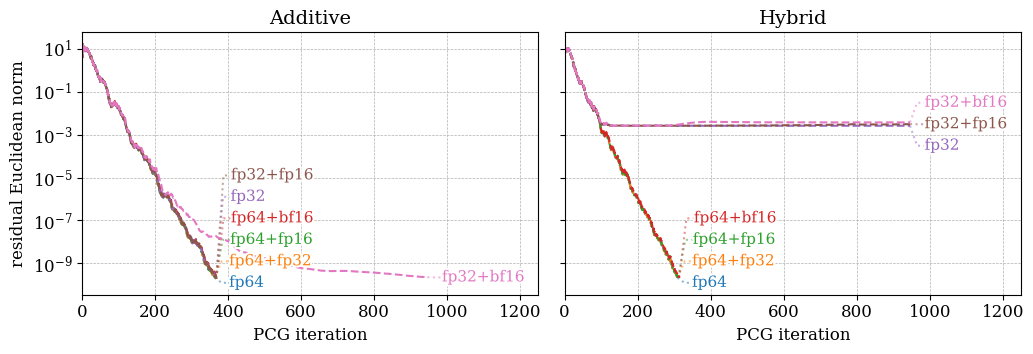

In [13]:
fig, axes = plt.subplots(ncols=2, figsize=(10.5, 3.7), sharey=True, layout="tight")

convergence_plot(
    ax=axes[0],
    df=df[
        (df["p"] == 5)
        & (df["coarse m"] == "S6")
        & (df["solver"].str.contains("CG"))
        & (df["solver"].str.contains("AdditiveSchwarz"))
    ],
    label_y=[-9.9, -8.9, -7.9, -6.9, -5.9, -4.9, -9.65],
    label_offset=40,
    first_iter=1,
    xlim=1250,
)
axes[0].set_title("Additive")

convergence_plot(
    ax=axes[1],
    df=df[
        (df["p"] == 5)
        & (df["coarse m"] == "S6")
        & (df["solver"].str.contains("CG"))
        & (df["solver"].str.contains("HybridSchwarz"))
    ],
    label_y=[-9.9, -8.9, -7.9, -6.9, -3.52, -2.52, -1.52],
    label_offset=40,
    max_iters=947,
    xlim=1250,
)
axes[1].set_title("Hybrid")

axes[0].set_ylabel("residual Euclidean norm")
fig.savefig("../docs/images/precision_residuals.svg", bbox_inches="tight")

## Speedups

In [14]:
def get_speedups(
    what="cg time", preconditioner="AdditiveSchwarz", base_precision="float64"
):
    times = summary[what][preconditioner].drop(index=11, level="fine m").copy()
    for prec in times.columns:
        if prec != base_precision:
            times[prec] = times[base_precision] / times[prec]
    times[base_precision] = 1.0
    existing_prec_order = [prec for prec in precisions_order if prec in times.columns]
    return times[existing_prec_order]

In [15]:
get_speedups(
    what="cg time",
    preconditioner="AdditiveSchwarz",
    base_precision="float64",
)

precision              float64  float64+float32  float64+float16  \
dim p fine m coarse m                                              
2D  1 10     8             1.0         1.196515         1.340750   
             9             1.0         1.017533         1.034058   
             10            1.0         0.997846         1.000681   
    3 9      7             1.0         1.394009         1.749387   
             8             1.0         1.123266         1.188593   
             9             1.0         1.019395         1.021691   
    5 8      6             1.0         1.486977         1.921790   
             7             1.0         1.179158         1.304868   
             8             1.0         1.047071         1.066950   

precision              float64+bfloat16   float32  float32+float16  \
dim p fine m coarse m                                                
2D  1 10     8                 1.339663  1.276516         1.434903   
             9                 0.996614  1.112745         1.136341   
             10                0.979322  1.112592         1.111272   
    3 9      7                 1.732965  1.419500         1.781303   
             8                 1.180478  1.190595         1.267027   
             9                 1.011369  1.114299         1.117660   
    5 8      6                 1.910804  1.476443         1.908444   
             7                 1.286994  1.222522         1.353381   
             8                 1.043971  1.119519         1.141091   

precision              float32+bfloat16  
dim p fine m coarse m                    
2D  1 10     8                 1.432914  
             9                 1.097108  
             10                1.087395  
    3 9      7                 1.765568  
             8                 1.258279  
             9                 1.108540  
    5 8      6                 0.745433  
             7                 1.319718  
             8                 1.118224